# Лабораторная работа 1. Методы пакетной обработки данных

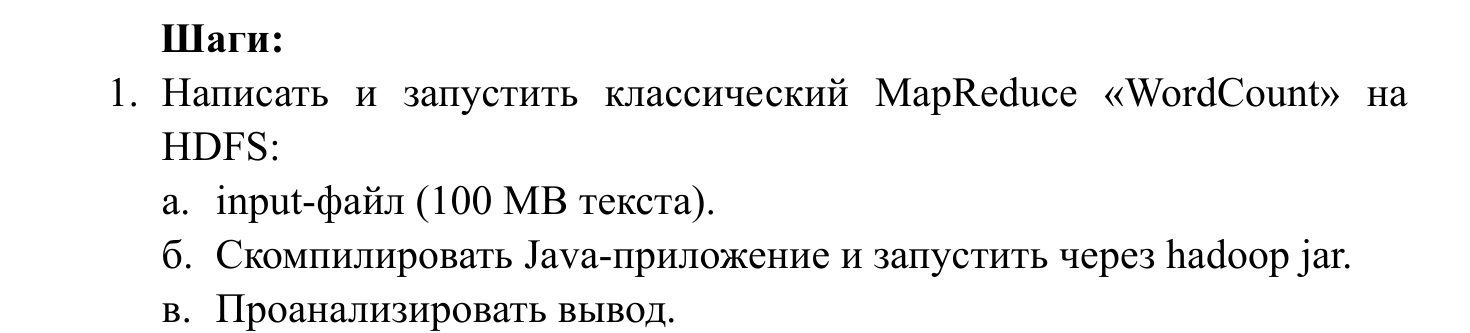

In [ ]:
# input-файл (100 mb текста)
!ls -lh "/Users/vladsuman/git/famcs/university_homework/famcs_homework/AOBD/лаб1/code/hadoop-wordcount/data/input.txt"

-rw-r--r--@ 1 vladsuman  staff   101M Sep 27 16:13 /Users/vladsuman/git/famcs/university_homework/famcs_homework/AOBD/лаб1_new/code/hadoop-wordcount/data/input.txt


`hadoop-wordcount/src/WordCount.java`:

```java
public class WordCount {

    // Mapper<KEYIN, VALUEIN, KEYOUT, VALUEOUT> - 4 типа задают, что мапер
    // получает на вход и что отдаёт дальше на reduce
    public static class TokenizerMapper extends Mapper<
            Object,       // KEYIN - ключ входной записи (для файла - номер байта, не используется)
            Text,         // VALUEIN - значение входной записи, для файла это сама строка текста
            Text,         // KEYOUT - ключ, который мапер отдаёт дальше - у нас слово
            IntWritable>  // VALUEOUT - значение, которое мапер отдаёт дальше - у нас единица
    {
        // IntWritable / Text - обёртки hadoop над int/String
        private final static IntWritable one = new IntWritable(1);
        private Text word = new Text();

        // map вызывается hadoop'ом отдельно для каждой строки входного файла
        // context - канал, через который мапер отдаёт результат в reduce
        public void map(Object key, Text value, Context context) throws IOException, InterruptedException {
            StringTokenizer itr = new StringTokenizer(value.toString()); // бьём строку на слова по пробелам
            while (itr.hasMoreTokens()) {
                word.set(itr.nextToken());
                context.write(word, one); // отдаём пару (слово, 1)
            }
        }
    }

    // Reducer<KEYIN, VALUEIN, KEYOUT, VALUEOUT> - те же 4 типа, но со стороны reduce
    public static class IntSumReducer extends Reducer<
            Text,         // KEYIN - слово (тот же тип, что KEYOUT у мапера)
            IntWritable,  // VALUEIN - единицы или частичные суммы от комбайнера для этого слова
            Text,         // KEYOUT - слово, идёт в результат как есть
            IntWritable>  // VALUEOUT - посчитанная сумма
    {
        private IntWritable result = new IntWritable();

        // reduce вызывается один раз на каждое уникальное слово,
        // values - все единицы, которые пришли для этого слова со всех маперов
        public void reduce(Text key, Iterable<IntWritable> values, Context context)
                throws IOException, InterruptedException {
            int sum = 0;
            for (IntWritable val : values) {
                sum += val.get();
            }
            result.set(sum);
            context.write(key, result); // пишем (слово, итоговое количество) в выходной файл
        }
    }

    public static void main(String[] args) throws Exception {
        Configuration conf = new Configuration(); // настройки hadoop
        Job job = Job.getInstance(conf, "word count"); // описание задачи, которую нужно прогнать на кластере
        job.setJarByClass(WordCount.class); // по этому классу hadoop поймёт, какой jar раздать по кластеру
        job.setMapperClass(TokenizerMapper.class);
        job.setCombinerClass(IntSumReducer.class); // тот же класс можно использовать как комбайнер - суммирование то же самое
        job.setReducerClass(IntSumReducer.class);
        job.setOutputKeyClass(Text.class);
        job.setOutputValueClass(IntWritable.class);
        FileInputFormat.addInputPath(job, new Path(args[0]));   // путь к входному файлу в hdfs
        FileOutputFormat.setOutputPath(job, new Path(args[1])); // путь, куда записать результат в hdfs
        System.exit(job.waitForCompletion(true) ? 0 : 1); // запускаем и ждём, пока job закончится
    }
}
```

In [ ]:
# развернуть hadoop-контейнер
!docker rm -f aobd-hadoop >/dev/null 2>&1
!docker run -d --name aobd-hadoop -p 9870:9870 -p 8088:8088 \
    -v "/Users/vladsuman/git/famcs/university_homework/famcs_homework/AOBD/лаб1/code/hadoop-wordcount/data:/data" \
    aobd-hadoop:lab1
!sleep 10

76a9676e2cf96989263f32aa30cb19d10146d5bf043135310dfb3934b3607afa


In [3]:
# input-файл (100 mb текста) -> hdfs
!docker exec aobd-hadoop bash -c "hdfs dfs -mkdir -p /input && hdfs dfs -put -f /data/input.txt /input/input.txt && hdfs dfs -ls -h /input" 

2026-09-27 17:14:55,216 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


2026-09-27 17:14:55,766 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


2026-09-27 17:14:57,047 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Found 1 items
-rw-r--r--   1 root supergroup    101.2 M 2026-09-27 17:14 /input/input.txt


**`hdfs dfs`** — команда для работы с файлами внутри HDFS.
- `-mkdir -p /input` — создать папку `/input` в HDFS
- `-put -f /data/input.txt /input/input.txt` — скопировать файл из файловой системы контейнера (`/data/input.txt`, примонтировано через `-v`) внутрь HDFS по пути `/input/input.txt`. `-f` — перезаписать, если файл там уже лежит
- `-ls -h /input` — показать список файлов в папке `/input`, размер — в мегабайтах/гигабайтах

In [ ]:
# скомпилировать java-приложение и запустить через hadoop jar
!docker cp "/Users/vladsuman/git/famcs/university_homework/famcs_homework/AOBD/лаб1/code/hadoop-wordcount/src/WordCount.java" aobd-hadoop:/opt/hadoop/WordCount.java
!docker exec aobd-hadoop bash -c "cd /opt/hadoop && rm -rf classes wordcount.jar && mkdir classes && javac -classpath \$(hadoop classpath) -d classes WordCount.java && jar -cf wordcount.jar -C classes ." 

Successfully copied 2.41kB (transferred 4.1kB) to aobd-hadoop:/opt/hadoop/WordCount.java


**`docker cp`** — скопировать файл с компьютера внутрь контейнера.

**`javac`** — компиляция java-кода.
- `-classpath $(hadoop classpath)` — говорит компилятору, где искать классы
- `hadoop classpath` — отдельная команда, которая печатает список путей ко всем hadoop-библиотекам
- `-d classes` — куда положить скомпилированные файлы

**`jar -cf wordcount.jar -C classes .`** — упаковать скомпилированные классы в один jar-файл, который потом отдаём Hadoop на выполнение.
- `-c` — create
- `-f wordcount.jar` — имя jar-файла
- `-C classes .` — взять все файлы из папки `classes`

In [5]:
# запустить через hadoop jar
!docker exec aobd-hadoop bash -c "cd /opt/hadoop && hdfs dfs -rm -r -f /output >/dev/null 2>&1; hadoop jar wordcount.jar WordCount /input/input.txt /output" 

2026-09-27 17:14:59,375 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


2026-09-27 17:14:59,613 INFO client.DefaultNoHARMFailoverProxyProvider: Connecting to ResourceManager at /0.0.0.0:8032


2026-09-27 17:14:59,833 WARN mapreduce.JobResourceUploader: Hadoop command-line option parsing not performed. Implement the Tool interface and execute your application with ToolRunner to remedy this.
2026-09-27 17:14:59,836 INFO mapreduce.JobResourceUploader: Disabling Erasure Coding for path: /tmp/hadoop-yarn/staging/root/.staging/job_1790529290670_0001


2026-09-27 17:14:59,941 INFO input.FileInputFormat: Total input files to process : 1


2026-09-27 17:15:00,793 INFO mapreduce.JobSubmitter: number of splits:1


...

2026-09-27 17:15:05,568 INFO mapreduce.Job: Job job_1790529290670_0001 running in uber mode : false
2026-09-27 17:15:05,570 INFO mapreduce.Job:  map 0% reduce 0%


2026-09-27 17:15:12,639 INFO mapreduce.Job:  map 100% reduce 0%


2026-09-27 17:15:15,668 INFO mapreduce.Job:  map 100% reduce 100%


2026-09-27 17:15:16,689 INFO mapreduce.Job: Job job_1790529290670_0001 completed successfully
2026-09-27 17:15:16,742 INFO mapreduce.Job: Counters: 54
	File System Counters
		FILE: Number of bytes read=662930
		FILE: Number of bytes written=1346915
		FILE: Number of read operations=0
		FILE: Number of large read operations=0
		FILE: Number of write operations=0
		HDFS: Number of bytes read=106127052
		HDFS: Number of bytes written=117759
		HDFS: Number of read operations=8
		HDFS: Number of large read operations=0
		HDFS: Number of write operations=2
		HDFS: Number of bytes read erasure-coded=0
	Job Counters 
		Launched map tasks=1
		Launched reduce tasks=1
		Data-local map tasks=1
		Total time spent by all maps in occupied slots (ms)=4734
		Total time spent by all reduces in occupied slots (ms)=872
		Total time spent by all map tasks (ms)=4734
		Total time spent by all reduce tasks (ms)=872
		Total vcore-milliseconds taken by all map tasks=4734
		Total vcore-milliseconds taken by all 

-milliseconds taken by all reduce tasks=892928
	Map-Reduce Framework
		Map input records=840000
		Map output records=10080000
		Map output bytes=146446950
		Map output materialized bytes=132586
		Input split bytes=102
		Combine input records=10111996
		Combine output records=39995
		Reduce input groups=7999
		Reduce shuffle bytes=132586
		Reduce input records=7999
		Reduce output records=7999
		Spilled Records=47994
		Shuffled Maps =1
		Failed Shuffles=0
		Merged Map outputs=1
		GC time elapsed (ms)=64
		CPU time spent (ms)=5650
		Physical memory (bytes) snapshot=755585024
		Virtual memory (bytes) snapshot=4968935424
		Total committed heap usage (bytes)=774373376
		Peak Map Physical memory (bytes)=497422336
		Peak Map Virtual memory (bytes)=2482135040
		Peak Reduce Physical memory (bytes)=258162688
		Peak Reduce Virtual memory (bytes)=2486800384
	Shuffle Errors
		BAD_ID=0
		CONNECTION=0
		IO_ERROR=0
		WRONG_LENGTH=0
		WRONG_MAP=0
		WRONG_REDUCE=0
	File Input Format Counters 
		Bytes Re

**`hadoop jar wordcount.jar WordCount /input/input.txt /output`** запускает job на кластере: `wordcount.jar` — наш джарник, `WordCount` — класс с `main`, `/input/input.txt` и `/output` — вход и выход в HDFS (`args[0]` и `args[1]`).

```
Launched map tasks=1
Launched reduce tasks=1
```
Запустилась одна map-задача и одна reduce-задача. Файл (101 МБ) меньше блока HDFS (128 МБ), весь файл лежит в одном блоке.

```
Map input records=840000
Map output records=10080000
```
На вход map пришло 840 000 записей — число строк в `input.txt`. На выход — 10 080 000 пар `(слово, 1)`, в среднем 12 слов на строку (10 080 000 / 840 000 = 12).

```
Map output bytes=146446950
Combine input records=10111996
Combine output records=39995
Reduce shuffle bytes=132586
```
Без суммировщика (`Combiner`) по сети поехало бы 146 446 950 байт (`Map output bytes`). Суммировщик принял 10 111 996 записей и уже на стороне map сложил повторяющиеся слова, оставив 39 995 (`Combine output records`) — и по сети в итоге ушло всего 132 586 байт (`Reduce shuffle bytes`), в 1100 раз меньше.

```
Reduce input records=7999
Reduce output records=7999
```
39 995 записей после суммировщика — это ещё не 7999 уникальных слов, суммировщик сработал частично. Полное объединение по каждому слову произошло уже на reduce: пришло 7999, вышло 7999.

In [6]:
# проанализировать вывод
!docker exec aobd-hadoop bash -c "hdfs dfs -cat /output/part-r-00000 | sort -k2 -n -r | head -15"
!docker exec aobd-hadoop bash -c "hdfs dfs -cat /output/part-r-00000 | wc -l" 

2026-09-27 17:15:17,335 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


galactosis	1053038
unidolatrous	528069
abut	351414
auxinic	263085
bloodstone	210471
erythrogenic	176175
tulipa	150675
currishness	132154
foreboot	117400
irrefutable	105636
nonexpansive	95953
cardinalitian	87745
inoxidize	81273
nycticorax	75066
subultimate	70437


2026-09-27 17:15:18,214 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


7999


Всего 7999 уникальных слов (`wc -l`).

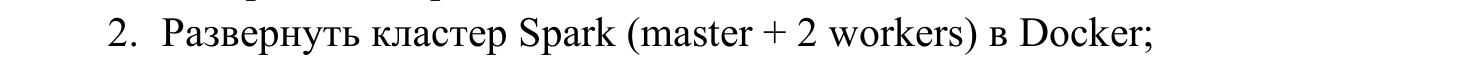

`spark-cluster/docker-compose.yml` — 1 master + 2 worker. `spark-master` координирует, `spark-worker-1`/`spark-worker-2` выполняют задачи.

In [ ]:
# развернуть кластер spark
!cd "/Users/vladsuman/git/famcs/university_homework/famcs_homework/AOBD/лаб1/code/spark-cluster" && docker compose --ansi never up -d
!sleep 5
!cd "/Users/vladsuman/git/famcs/university_homework/famcs_homework/AOBD/лаб1/code/spark-cluster" && docker compose ps

 Container aobd-spark-master Running 
 Container aobd-spark-worker-1 Running 
 Container aobd-spark-worker-2 Running 


NAME                  IMAGE                COMMAND                  SERVICE          CREATED          STATUS          PORTS
aobd-spark-master     apache/spark:3.5.3   "/opt/entrypoint.sh …"   spark-master     22 minutes ago   Up 22 minutes   0.0.0.0:4040->4040/tcp, [::]:4040->4040/tcp, 0.0.0.0:7077->7077/tcp, [::]:7077->7077/tcp, 0.0.0.0:8080->8080/tcp, [::]:8080->8080/tcp
aobd-spark-worker-1   apache/spark:3.5.3   "/opt/entrypoint.sh …"   spark-worker-1   2 hours ago      Up 2 hours      0.0.0.0:8081->8081/tcp, [::]:8081->8081/tcp
aobd-spark-worker-2   apache/spark:3.5.3   "/opt/entrypoint.sh …"   spark-worker-2   2 hours ago      Up 2 hours      0.0.0.0:8082->8081/tcp, [::]:8082->8081/tcp


In [8]:
# оба worker подключились к master
!docker logs aobd-spark-master 2>&1 | grep -i "registering worker" 

26/09/27 16:53:16 INFO Master: Registering worker 172.20.0.4:45533 with 2 cores, 2.0 GiB RAM
26/09/27 16:53:19 INFO Master: Registering worker 172.20.0.3:44139 with 2 cores, 2.0 GiB RAM


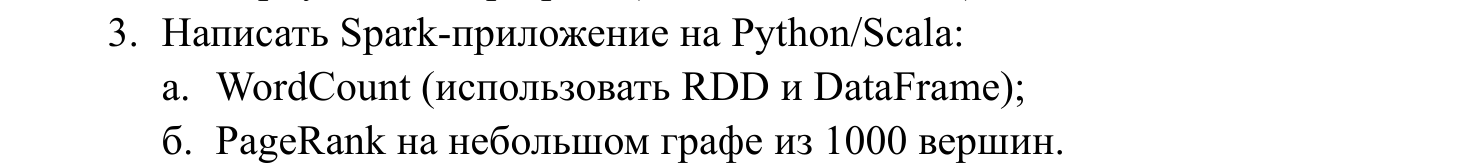

`spark-apps/src/main/scala/WordCountRDD.scala`:

```scala
import org.apache.spark.{SparkConf, SparkContext}

object WordCountRDD {
  def main(args: Array[String]): Unit = {
    val inputPath = args(0)
    val outputPath = args(1)

    val conf = new SparkConf().setAppName("WordCountRDD") // настройки приложения
    val sc = new SparkContext(conf)
    sc.setLogLevel("WARN")

    val lines = sc.textFile(inputPath)          // читаем файл - каждая строка становится отдельным элементом
    val words = lines.flatMap(_.split("\\s+"))  // разбиваем каждую строку на слова
    val pairs = words.map(word => (word, 1))    // каждому слову ставим в пару 1
    val counts = pairs.reduceByKey(_ + _)       // складываем значения с одинаковым словом (_ + _ - сложение двух чисел)

    counts.saveAsTextFile(outputPath)
    sc.stop()
  }
}
```

`spark-apps/src/main/scala/WordCountDF.scala`:

```scala
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._

object WordCountDF {
  def main(args: Array[String]): Unit = {
    val inputPath = args(0)
    val outputPath = args(1)

    val spark = SparkSession.builder().appName("WordCountDF").getOrCreate()
    spark.sparkContext.setLogLevel("WARN")

    val lines = spark.read.text(inputPath)  // читаем файл - одна колонка value, в ней целая строка файла
    val splitWords = split(col("value"), "\\s+")  // split разбивает строку на массив слов
    val words = lines.select(explode(splitWords).as("word"))  // explode разворачивает массив в отдельные строки - одно слово на строку
    val grouped = words.groupBy("word")  // группируем строки по слову
    val counts = grouped.count()  // считаем размер каждой группы - количество вхождений слова

    counts.write.mode("overwrite").csv(outputPath)
    spark.stop()
  }
}
```

In [9]:
# spark-приложение на rdd
!docker exec aobd-spark-master bash -c "rm -rf /workspace/spark-apps/data/output_rdd && /opt/spark/bin/spark-submit --master spark://spark-master:7077 --class WordCountRDD /workspace/spark-apps/target/scala-2.12/spark-apps_2.12-1.0.jar /workspace/hadoop-wordcount/data/input.txt /workspace/spark-apps/data/output_rdd 2>/dev/null" 

**`spark-submit`** отправляет приложение на кластер:
- `--master spark://spark-master:7077` — адрес master, куда отправить задачу
- `--class WordCountRDD` — какой класс с `main` запускать внутри jar
- дальше сам jar, потом `args(0)` и `args(1)` — входной и выходной путь

In [10]:
# проверить результат
!docker exec aobd-spark-master bash -c "cat /workspace/spark-apps/data/output_rdd/part-* | wc -l" 

7999


7999 уникальных слов — совпадает с ранее полученным результатом.

In [11]:
# spark-приложение на dataframe
!docker exec aobd-spark-master bash -c "rm -rf /workspace/spark-apps/data/output_df && /opt/spark/bin/spark-submit --master spark://spark-master:7077 --class WordCountDF /workspace/spark-apps/target/scala-2.12/spark-apps_2.12-1.0.jar /workspace/hadoop-wordcount/data/input.txt /workspace/spark-apps/data/output_df 2>/dev/null"
!docker exec aobd-spark-master bash -c "cat /workspace/spark-apps/data/output_df/*.csv | wc -l" 

7999


`spark-apps/src/main/scala/PageRank.scala`:

```scala
import org.apache.spark.{SparkConf, SparkContext}

object PageRank {
  def main(args: Array[String]): Unit = {
    val inputPath = args(0)
    val outputPath = args(1)
    val numVertices = args(2).toInt
    val iterations = args(3).toInt

    val conf = new SparkConf().setAppName("PageRank")
    val sc = new SparkContext(conf)
    sc.setLogLevel("WARN")

    // рёбра графа: строка "откуда\tкуда" -> пара (src, dst)
    val edges = sc.textFile(inputPath).map { line =>
      val parts = line.split("\t")
      (parts(0).toInt, parts(1).toInt)
    }

    val allVertices = sc.parallelize(0 until numVertices)

    val verticesWithNoOutgoing = allVertices.map(v => (v, Iterable.empty[Int])) // каждой вершине - пустой список исходящих рёбер
    val groupedEdges = edges.groupByKey() // группируем рёбра по вершине-источнику: (вершина, список тех, на кого она ссылается)
    val links = verticesWithNoOutgoing.union(groupedEdges) // объединяем - теперь у каждой вершины есть запись (пустая или с рёбрами)
      .reduceByKey(_ ++ _) // если для вершины есть и пустая, и реальная запись - склеиваем их в одну
      .persist() // держит в памяти, чтобы не пересчитывать links заново на каждой итерации

    var ranks = links.mapValues(_ => 1.0) // изначально у всех вершин одинаковый ранг

    for (_ <- 1 to iterations) {
      val linksWithRanks = links.join(ranks) // сводим вместе для каждой вершины её список ссылок и её текущий ранг
      val contributions = linksWithRanks.flatMap { case (_, (dests, rank)) =>
        // вершина отдаёт свой ранг поровну всем, на кого ссылается
        if (dests.isEmpty) Iterable.empty else dests.map(dest => (dest, rank / dests.size))
      }
      val received = contributions.reduceByKey(_ + _) // складываем все вклады, пришедшие на каждую вершину

      val verticesWithZero = allVertices.map(v => (v, 0.0)) // вершины без входящих ссылок не попадут в received - поэтому всем сначала даём 0.0
      ranks = verticesWithZero.union(received)
        .reduceByKey(_ + _) // если для вершины есть и 0.0, и реальный вклад - складываем (0 ничего не меняет)
        .mapValues(sum => 0.15 + 0.85 * sum) // формула PageRank с коэффициентом затухания 0.85
    }

    ranks.sortBy(_._2, ascending = false).saveAsTextFile(outputPath)
    sc.stop()
  }
}
```

Граф: `spark-apps/data/graph_edges.txt` — 1000 вершин, 5979 рёбер, строка `откуда\tкуда`.

In [12]:
# pagerank на графе из 1000 вершин
!docker exec aobd-spark-master bash -c "rm -rf /workspace/spark-apps/data/output_pagerank && /opt/spark/bin/spark-submit --master spark://spark-master:7077 --class PageRank /workspace/spark-apps/target/scala-2.12/spark-apps_2.12-1.0.jar /workspace/spark-apps/data/graph_edges.txt /workspace/spark-apps/data/output_pagerank 1000 10 2>/dev/null" 

In [13]:
# топ вершин по рангу
!docker exec aobd-spark-master bash -c "cat /workspace/spark-apps/data/output_pagerank/part-* | head -10"
!docker exec aobd-spark-master bash -c "cat /workspace/spark-apps/data/output_pagerank/part-* | wc -l" 

(0,88.64966175538629)
(1,47.78731208916383)
(2,29.20475515551757)
(3,29.1859752681159)
(4,22.544567133820202)
(5,17.607521131739063)
(10,8.443991364703539)
(8,7.3110423128803586)
(13,6.872468262607725)
(9,6.817605873927821)


1000


1000 строк на выходе — ранг посчитан для каждой вершины. У вершины 0 самый высокий ранг (88.6), дальше по убыванию — 1, 2, 3 и так далее.

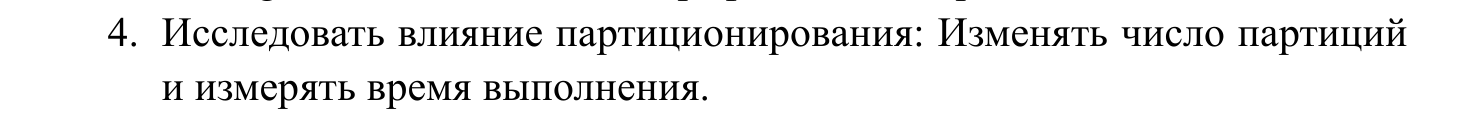

Spark делит входные данные на партиции — кусочки, которые обрабатываются отдельными задачами, по одной задаче на партицию. У кластера 4 ядра (по 2 на каждом из 2 worker'ов), значит одновременно может выполняться максимум 4 задачи. Если партиций меньше 4 — часть ядер простаивает. Если партиций намного больше 4 — ядра всё равно заняты, но на каждую мелкую задачу уходит время на её запуск и учёт, и это накладные расходы начинают перевешивать.

`spark-apps/src/main/scala/PartitioningExperiment.scala`:

```scala
import org.apache.spark.{SparkConf, SparkContext}
import org.apache.spark.rdd.RDD

object PartitioningExperiment {
  def main(args: Array[String]): Unit = {
    val inputPath = args(0)
    val mode = args(1) // "scan" - перебор чисел партиций, "repartition-coalesce" - сравнение repartition/coalesce

    val conf = new SparkConf().setAppName("PartitioningExperiment")
    val sc = new SparkContext(conf)
    sc.setLogLevel("WARN")

    // запускает wordcount над готовым rdd и возвращает время выполнения в мс
    def timeIt(lines: RDD[String]): Long = {
      val start = System.currentTimeMillis()
      lines.flatMap(_.split("\\s+")).map(w => (w, 1)).reduceByKey(_ + _).count() // action - без неё вычисление не запустится
      System.currentTimeMillis() - start
    }

    timeIt(sc.textFile(inputPath)) // прогрев - тот же пайплайн один раз до замеров

    mode match {
      case "scan" =>
        // список чисел партиций для перебора; если не передали - берём значения по умолчанию
        val partitionCounts = if (args.length > 2) args(2).split(",").map(_.toInt) else Array(1, 2, 4, 8, 16, 32, 128)
        for (n <- partitionCounts) {
          val lines = sc.textFile(inputPath, n) // n - минимальное число партиций при чтении файла
          println(s"partitions=$n actual=${lines.getNumPartitions} time_ms=${timeIt(lines)}")
        }
```

In [14]:
# менять число партиций и измерять время выполнения
!docker exec aobd-spark-master bash -c "/opt/spark/bin/spark-submit --master spark://spark-master:7077 --class PartitioningExperiment /workspace/spark-apps/target/scala-2.12/spark-apps_2.12-1.0.jar /workspace/hadoop-wordcount/data/input.txt scan 1,2,4,8,16,32,128 2>/dev/null" 

partitions=1 actual=4 time_ms=684


partitions=2 actual=4 time_ms=606


partitions=4 actual=4 time_ms=493


partitions=8 actual=8 time_ms=551


partitions=16 actual=16 time_ms=658


partitions=32 actual=32 time_ms=720


partitions=128 actual=128 time_ms=1605


Второй аргумент `textFile` — не точное число партиций, а нижняя граница (`minPartitions`). Наш файл (~101 МБ) режется минимум на 4 куска, поэтому `partitions=1` и `partitions=2` оба дали `actual=4`. Попросить больше, чем этот минимум, можно — тогда каждый кусок дробится мельче, и `actual` совпадает с запрошенным. Задать точное число партиций можно через `repartition`/`coalesce` после чтения файла.

Дальше, где `actual` уже отличается, время растёт вместе с числом партиций: 4 → 493 мс, 8 → 551 мс, 16 → 658 мс, 32 → 720 мс, 128 → 1605 мс. Минимум — на 4 партициях, ровно по числу ядер в кластере. При 128 партициях на файл в 101 МБ каждая партиция — это меньше 1 МБ, и время на запуск и учёт такого количества мелких задач перевешивает выигрыш от параллельности.

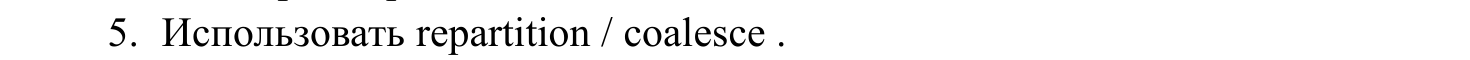

Добавлен режим `repartition-coalesce` в тот же файл, с перебором целевых чисел партиций:

```scala
      case "repartition-coalesce" =>
        // список целевых чисел партиций для repartition/coalesce; если не передали - берём значения по умолчанию
        val targets = if (args.length > 2) args(2).split(",").map(_.toInt) else Array(1, 2, 4, 8, 16)

        // repartition/coalesce меняют число партиций уже после чтения файла, а не при самом чтении
        val base = sc.textFile(inputPath) // естественное разбиение, без minPartitions
        println(s"base actual=${base.getNumPartitions} time_ms=${timeIt(base)}")

        for (n <- targets) {
          val repartitioned = base.repartition(n)
          println(s"repartition($n) actual=${repartitioned.getNumPartitions} time_ms=${timeIt(repartitioned)}")

          val coalesced = base.coalesce(n)
          println(s"coalesce($n) actual=${coalesced.getNumPartitions} time_ms=${timeIt(coalesced)}")
        }
    }
```

In [15]:
# repartition и coalesce на несколько целевых чисел партиций
!docker exec aobd-spark-master bash -c "/opt/spark/bin/spark-submit --master spark://spark-master:7077 --class PartitioningExperiment /workspace/spark-apps/target/scala-2.12/spark-apps_2.12-1.0.jar /workspace/hadoop-wordcount/data/input.txt repartition-coalesce 1,2,4,8,16 2>/dev/null" 

base actual=4 time_ms=635


repartition(1) actual=1 time_ms=1818


coalesce(1) actual=1 time_ms=1432


repartition(2) actual=2 time_ms=1078


coalesce(2) actual=2 time_ms=1029


...

coalesce(4) actual=4 time_ms=545


repartition(8) actual=8 time_ms=756


coalesce(8) actual=4 time_ms=543


repartition(16) actual=16 time_ms=829


coalesce(16) actual=4 time_ms=542


`coalesce(8)` и `coalesce(16)` оба остались на `actual=4` — с базовых 4 партиций `coalesce` не может подняться выше, только слить существующие в меньшее число. `repartition(8)` и `repartition(16)`, наоборот, дошли до запрошенного числа, потому что делают полный shuffle и могут разложить данные как угодно.

`repartition(4)` — 722 мс, хотя целевое число (4) совпадает с тем, что уже было в `base` (635 мс). `repartition` всё равно гоняет данные по сети, даже когда конечный результат не отличается от того, что уже есть — в отличие от `coalesce(4)` (545 мс), который в этом случае почти ничего не делает.

На уменьшении (1, 2, 4) `coalesce` каждый раз быстрее `repartition` при одинаковом `actual` — разница и есть стоимость shuffle, который `coalesce` не делает.

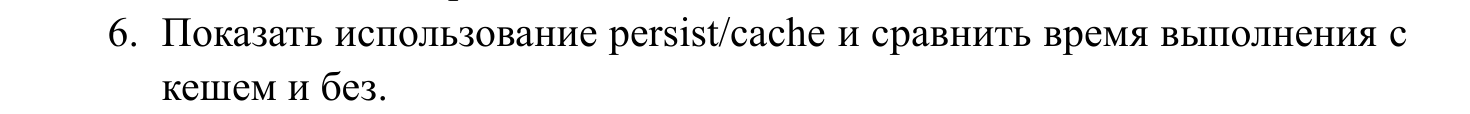

Добавлен режим `persist` в тот же файл:

```scala
      case "persist" =>
        def timeAction(words: RDD[String]): Long = {
          val start = System.currentTimeMillis()
          words.count()
          System.currentTimeMillis() - start
        }
        // специально медленная операция на каждое слово, чтобы пересчёт был заметно дороже кэша
        def words(): RDD[String] = sc.textFile(inputPath).flatMap(_.split("\\s+")).map { w =>
          var h = w.hashCode
          for (i <- 0 until 500) h = h * 31 + i
          w
        }

        val notCached = words()
        println(s"no_cache run1_ms=${timeAction(notCached)} run2_ms=${timeAction(notCached)}")

        val cached = words().persist()
        println(s"with_cache run1_ms=${timeAction(cached)} run2_ms=${timeAction(cached)}")
    }
```

In [16]:
# с кэшем и без - два count() на одном и том же rdd
!docker exec aobd-spark-master bash -c "/opt/spark/bin/spark-submit --master spark://spark-master:7077 --executor-memory 1800m --class PartitioningExperiment /workspace/spark-apps/target/scala-2.12/spark-apps_2.12-1.0.jar /workspace/hadoop-wordcount/data/input.txt persist 2>/dev/null" 

no_cache run1_ms=1633 run2_ms=1594


with_cache run1_ms=1980 run2_ms=67


`--executor-memory 1800m` — сколько памяти давать каждому executor'у (по умолчанию 1 ГБ, этого не хватило, чтобы закэшированные данные полностью влезли в память).

Без кэша оба запуска на одном RDD стабильно медленные: 1633 мс и 1594 мс — `count()` каждый раз пересчитывает всё заново, с чтения файла. С `persist()`: первый запуск — 1980 мс (чуть дольше обычного, потому что помимо счёта данные ещё и складываются в память), а второй — 67 мс, потому что второй `count()` берёт уже готовый результат из памяти, а не пересчитывает пайплайн.

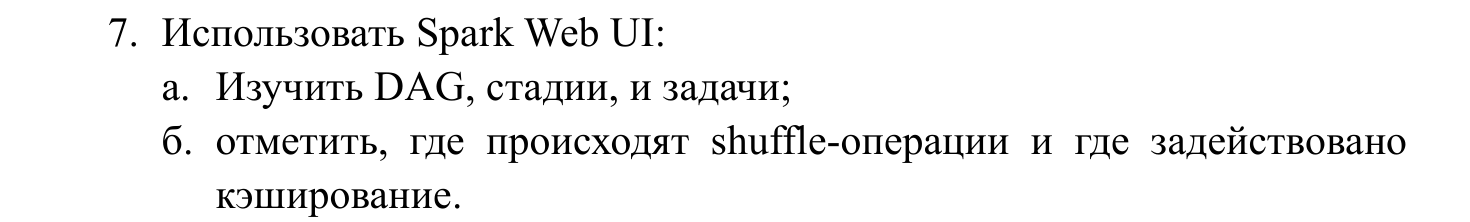

```bash
docker exec aobd-spark-master bash -c "/opt/spark/bin/spark-submit --master spark://spark-master:7077 --class PageRank /workspace/spark-apps/target/scala-2.12/spark-apps_2.12-1.0.jar /workspace/spark-apps/data/graph_edges.txt /workspace/spark-apps/data/output_pagerank 1000 10"
```

UI доступен на `http://localhost:4040` (конкретный job) и на `http://localhost:8080` (весь кластер, вкладка Running Applications)

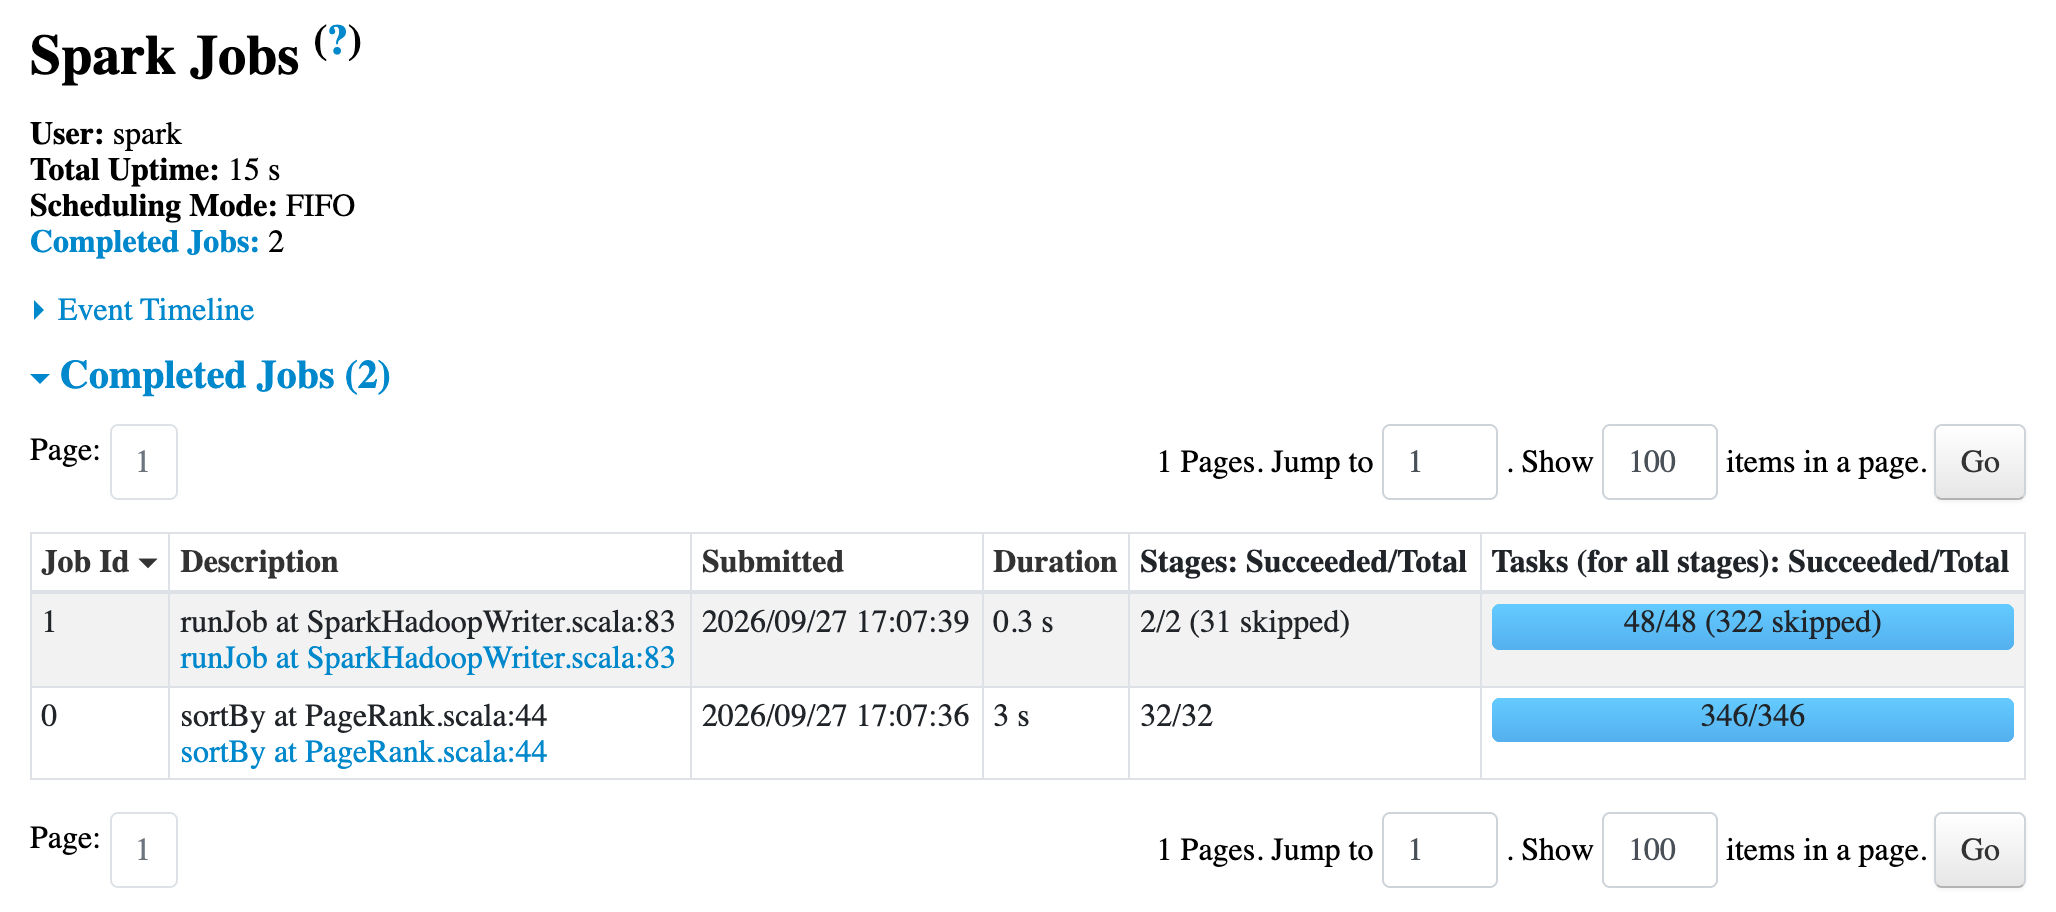

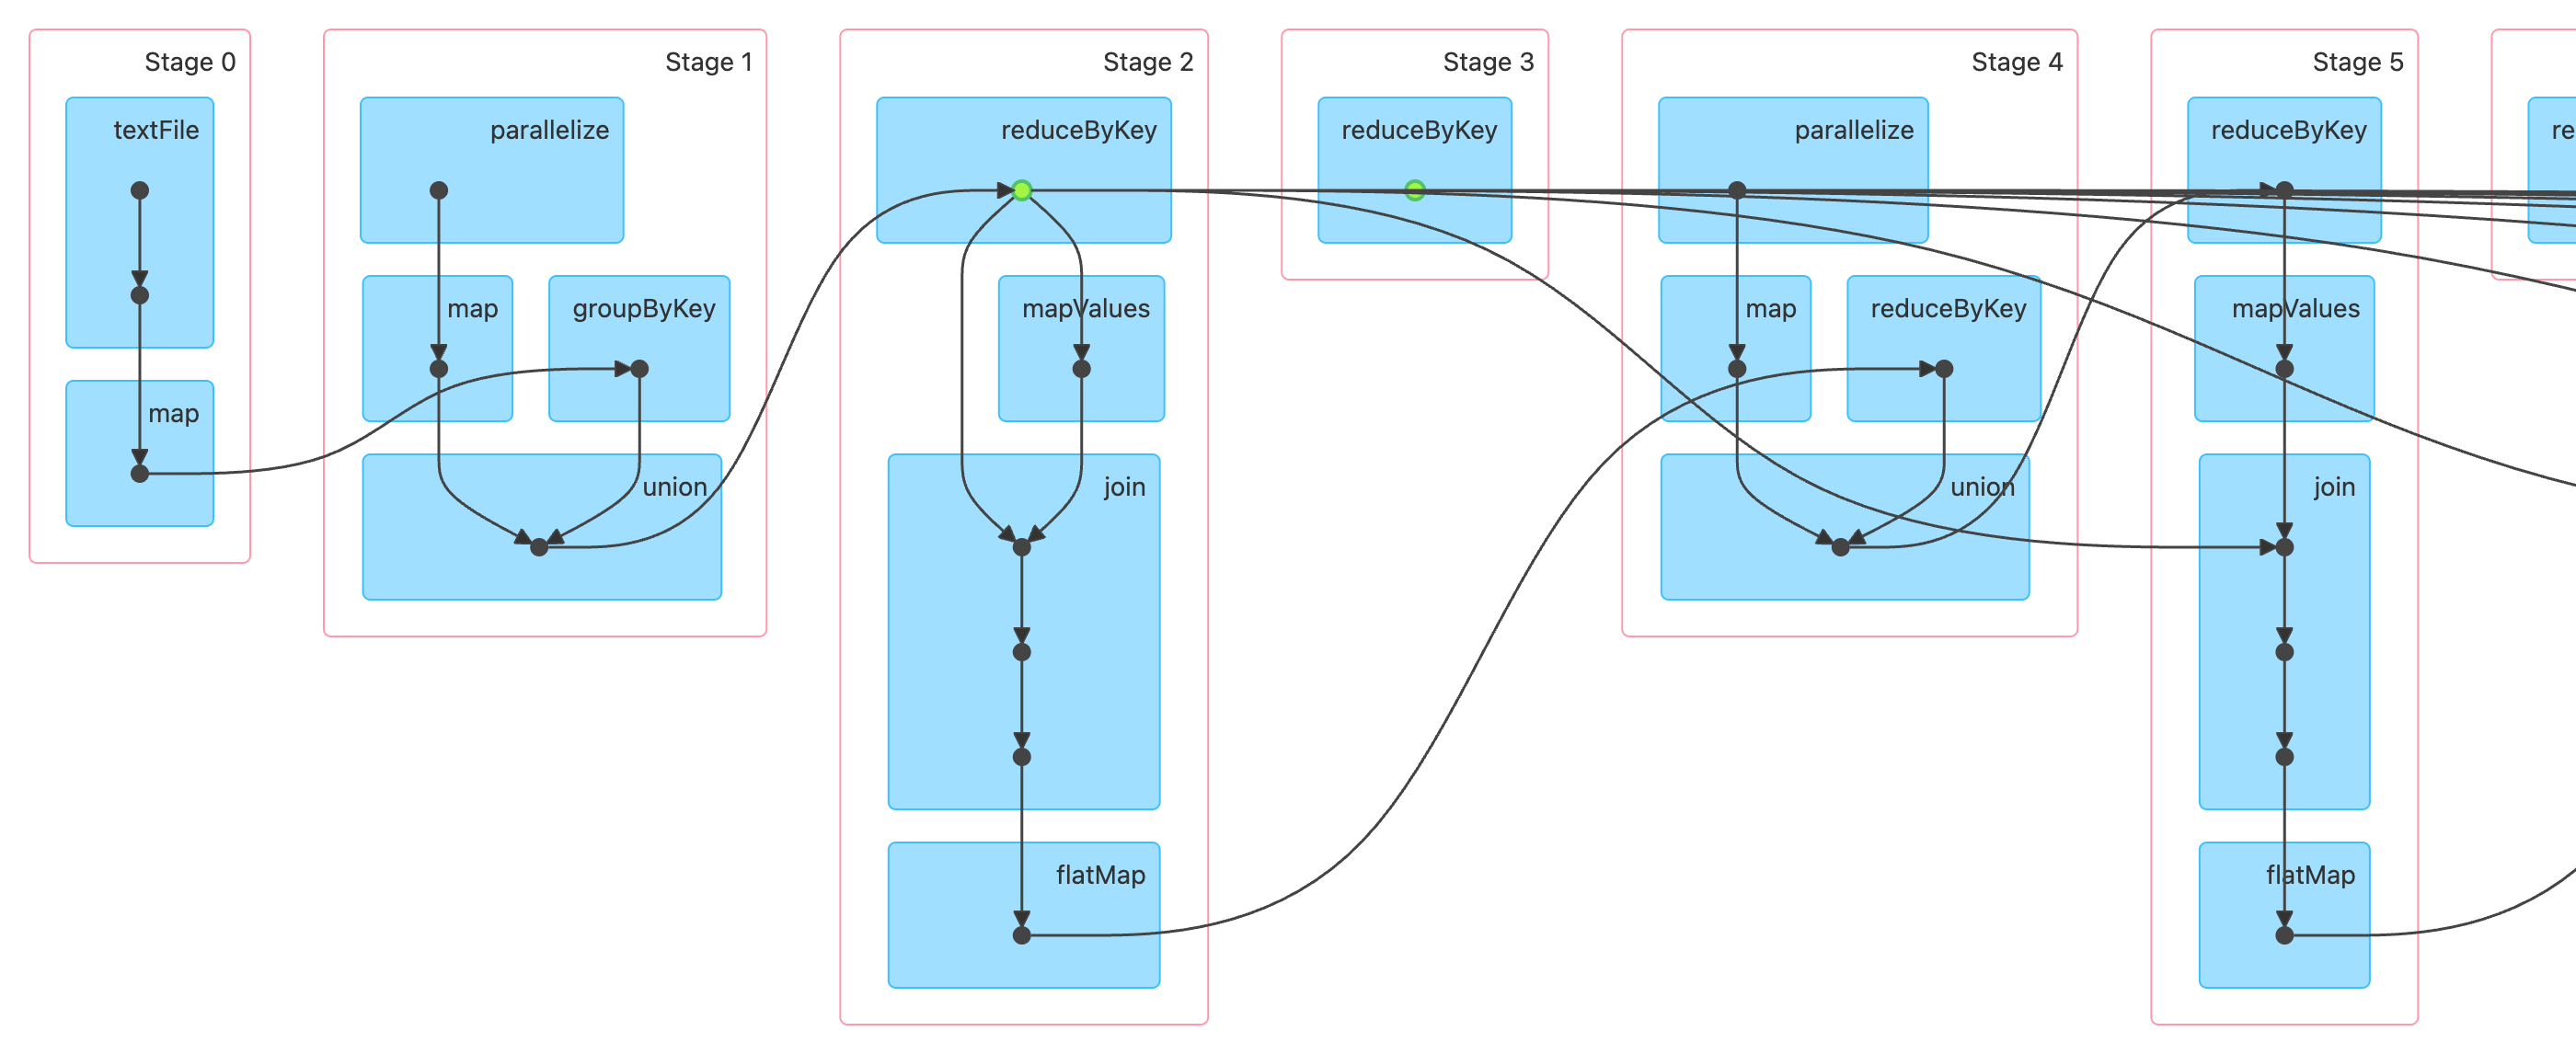

Job → Stages

границы между стадиями (Stage 0, Stage 1, Stage 2...) — это shuffle

`groupByKey`, `join`, `reduceByKey` завершают текущую стадию и начинают новую, потому что для них нужно перераспределить данные. 

внутри одной стадии (`map` → `map` → `flatMap`) операции просто идут одна за одной на тех же партициях, без пересылки.

зелёная точка на `reduceByKey` в Stage 2 и Stage 3 — это `.persist()`

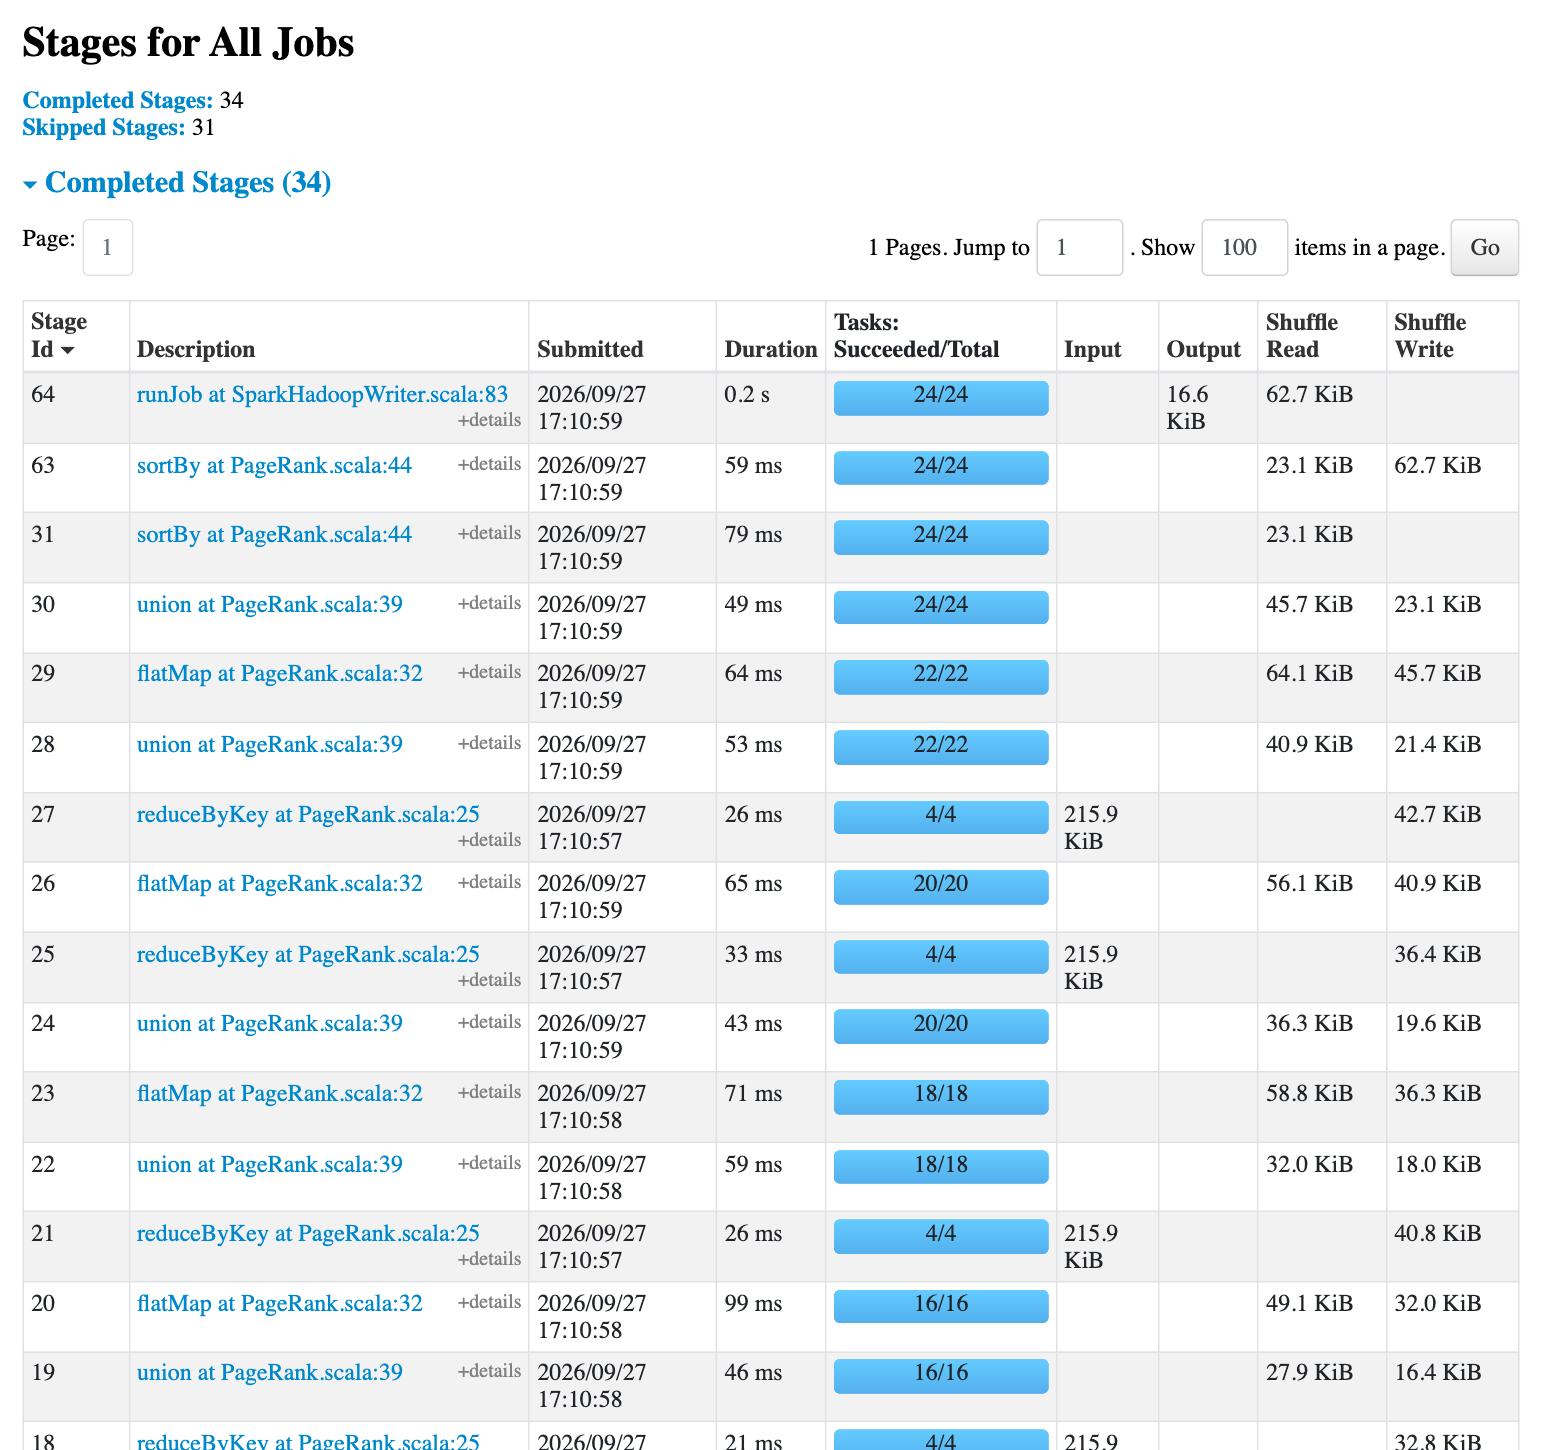

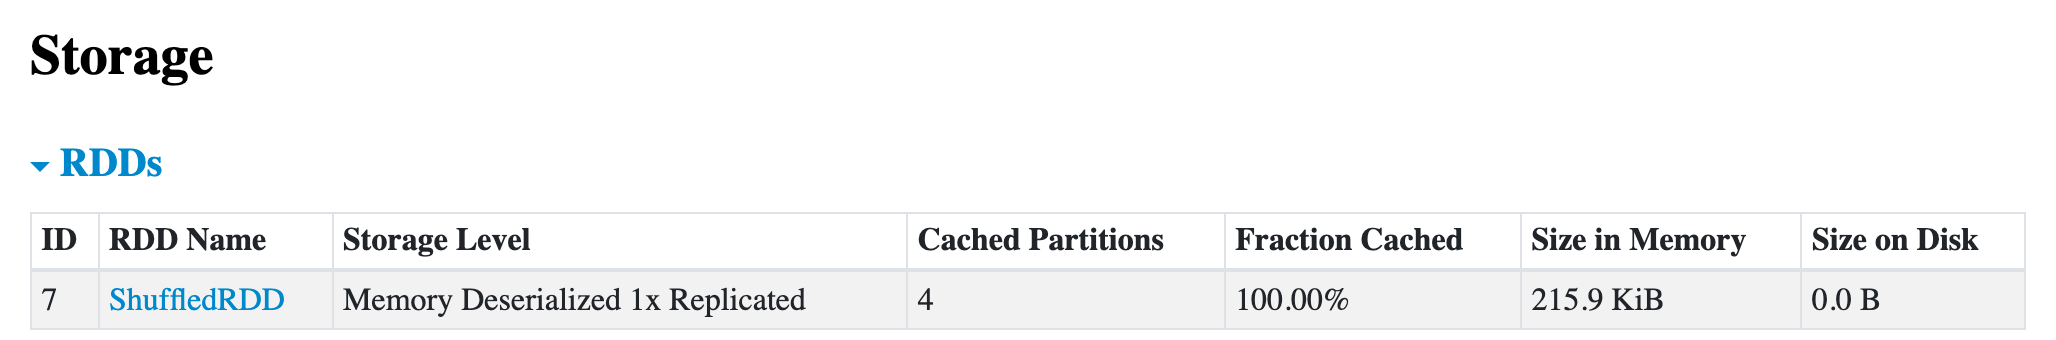